# Quickstart: GREmLN

> **Google Colab Note**: It is strongly recommended to run this notebook with an A100 GPU, which is only included with Google Colab Pro or Enterprise paid services. Alternatively, a "pay as you go" option is available to purchase premium GPUs. See [Colab Service Plans](https://colab.research.google.com/signup?utm_source=notebook_settings&utm_medium=link&utm_campaign=premium_gpu_selector) for details.

**GREmLN** (Gene Regulatory Embedding-based Large Neural model) is a foundation model designed to process single-cell RNA sequencing (scRNA-seq) data using the structure of gene regulatory networks (GRNs). Unlike conventional transformer models that treat gene expression data as a sequence of tokens, GREmLN integrates biologically meaningful relationships by embedding GRN structure directly into the model’s attention mechanism. This allows it to capture long-range regulatory dependencies and produce high-quality cell and gene embeddings that are useful for tasks such as cell type classification and regulatory network inference.

### **Inputs and Outputs**
**(Inputs)** There are two inputs to GREmLN:

1. A preprocessed scRNA-seq gene expression matrix `(cells × genes)`
2. A gene regulatory network (GRN), constructed for each cell type or cell lineage


**(Outputs)** For each cell, GREmLN produces an embedding matrix (`G x 512`) where:

1. Row `i` represents a 512-dimensional embedding vector for gene `i`.
2. Column `j` represents a learned hidden feature dimension shared across genes.


## Setup
GREmLN requires an NVIDIA GPU with compatible CUDA drivers (e.g., CUDA 11 or 12) for optimal performance. Its dependencies include a stack of high-performance libraries that are sensitive to your system’s CUDA version, GPU hardware, and operating system (especially differences between Linux, macOS, and Windows).

To avoid compatibility issues, we recommend installing critical dependencies such as PyTorch, PyTorch Lightning, and FlashAttention manually, following instructions specific to your hardware and OS.

GREmLN's `setup.py` assumes that `torch`, `torch-geometric` and `flash-attn` have already been installed and are compatible with your system. Once these are installed, clone the `scGraphLLM` package and run `pip install scGraphLLM`.


### Setup Google Colab

(note that you may have to restart your environment once you have successfully installed all dependencies)

If you are using Google Colab with an NVIDIA A100 GPU and CUDA 12.1, you can install the required dependencies with the following commands:

> **Note:** After installation, you may need to **restart the runtime** for changes to take effect.

> **Note:** An Ampere tier GPU is necessary for the tutorial because Flash Attention does not currently support T tier GPU's.


In [3]:
# Install PyTorch and torchvision etc. for CUDA 12.1
!pip install torch=='2.4.1+cu121' torchvision=='0.19.1+cu121' torchaudio=='2.4.1+cu121' --index-url https://download.pytorch.org/whl/cu121

# Install PyG packages (torch-geometric, torch-scatter etc) for CUDA 12.1
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.4.1+cu121.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.4.1+cu121.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.4.1+cu121.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.4.1+cu121.html
!pip install torch-geometric
!pip install lightning

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.4.1%2Bcu121-cp311-cp311-linux_x86_64.whl (799.0 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 79.4 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 56.0 MB/s eta 0:00:00:00:01
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached https://do

In [12]:
!module load cuda/12.1.1

Loading cuda/12.1.1
  Loading requirement: libxml2/2.9.7
>

In [ ]:
# Install flash-attn from PyPI if available for CUDA 12.1
!pip install flash-attn --no-build-isolation --extra-index-url https://download.pytorch.org/whl/cu121


You can clone the repo for GREmLN here: [https://github.com/czi-ai/reg-net-llm](https://github.com/czi-ai/reg-net-llm)

In [3]:
!git clone https://github.com/czi-ai/GREmLN.git

Cloning into 'GREmLN'...
remote: Enumerating objects: 2401, done.
remote: Counting objects: 100% (2401/2401), done.
remote: Compressing objects: 100% (762/762), done.
remote: Total 2401 (delta 1647), reused 2343 (delta 1600), pack-reused 0 (from 0)
Receiving objects: 100% (2401/2401), 9.73 MiB | 26.42 MiB/s, done.
Resolving deltas: 100% (1647/1647), done.


In [4]:
# # Install scGraphLLM with pip via setup.py once you have downloaded the repository
%cd GREmLN
!pip install .

/scratch/michele.calabro/gears/VCC/SPECTRA/GREmLN
Processing /scratch/michele.calabro/gears/VCC/SPECTRA/GREmLN
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.0 MB/s eta 0:00:00ta 0:00:01
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 377.1 kB/s eta 0:00:00a 0:00:01
  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached pynndescent-0.5.13-py3-none-any.whl.metadata (6.8 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached umap_learn-0.5.9.post2-py3-none-any.whl.metadata (25 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached array_api_compat-1.12.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metada

Download the model weights, ARACNe networks, and demo data for the tutorial via gdown (you can also find those assets [here](https://drive.google.com/drive/folders/1cMR9HoAC22i6sKSWgfQUEQRf0UP_w3_m?usp=sharing)).

In [6]:
!pip install gdown #gdown will enable us to download the tutorial assets from google drive

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 4.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [9]:
#%cd content - unnecessary if session was restarted, if not then you need to navigate back to the content directory

/bin/bash: line 0: cd: content: No such file or directory


In [7]:
!ls

build	    gremln.egg-info  notebooks	     scGraphLLM  uv.lock
cxg.ipynb   init.sh	     pyproject.toml  scripts
embeddings  install_env.sh   README.md	     setup.py
env.yml     LICENSE.md	     run.sh	     test


In [ ]:
!gdown --folder https://drive.google.com/drive/folders/1cMR9HoAC22i6sKSWgfQUEQRf0UP_w3_m?usp=sharing

Retrieving folder contents
Processing file 19RMsAKriM-rY6Y4u4SXQ_9nH3RASEVqT model.ckpt
Processing file 1SBy8C0BOeQV5C68V63tDXeaQW6Y3zLGc .DS_Store
Retrieving folder 1xgN0H3EKagBNm2_J1LpVzOCW-6sIr5O0 networks
Retrieving folder 1lKZwd6S2qnG6EPLMc-AnQf1XKKLjczI6 cd20_b_cells
Processing file 1HRm4S_HaXdDjyTt-JLz71-Ha2c4quaA6 network.tsv
Retrieving folder 17XelZp5_htLx58zaPqGvlu-FQSYN7z-2 erythrocytes
Processing file 1wRfvbn_v3NiyVetb-mO9ytXM3pAYBT5P network.tsv
Retrieving folder 191saUqqZKkX6Eyw35F3332kQdV0pWc8I cd16_monocytes
Processing file 17AQh02OmCTo0_hJp6eY_1UM6IEn7zVBc network.tsv
Retrieving folder 1acUBPLtTlZlCo_023yakTM4qISMu0es6 epithelial_cell
Processing file 1JTV_sEQvIEpCiBZBMRWwVMiiWhmp57lc network.tsv
Retrieving folder 1JB_EahNh3NkieVeMHtWnt-9AQP7psar7 nkt_cells
Processing file 1BmSvnG9ejWfFboYkBmcYscrNk6Yhgk8a network.tsv
Retrieving folder 1eQhWN6_jNx5TTQooSt4SoaNfTZHTyOCl cd4_t_cells
Processing file 1AeQHOfpHlT0sA6IlnN7uv7lx2Y_YmMn5 network.tsv
Retrieving folder 17f52EdtuA

In [ ]:
# Change to working directory to the GREmLN_Tutorial directory, containing demo data
import os
os.chdir("/content/GREmLN_Tutorial")
print("Current working directory:", os.getcwd())

Current working directory: /content/GREmLN_Tutorial


## Run Model Inference

To run model inference and generate single-cell embeddings with our trained model:

1. **Preprocess your data**

 Normalize raw counts using Counts Per Million (CPM), then apply a log1p transformation i.e., `log(1 + CPM)`

2. **Generate a gene regulatory network** (GRN):

  You can use any GRN inference method, but we recommend [ARACNe](https://califano.c2b2.columbia.edu/aracne/) for consistent and biologically meaningful results. *Note:* networks should be cell type specific.

3. **Prepare inputs with our API**:

  Use the provided `RegulatoryNetwork`,  `GraphTokenizer` and `InferenceDataset` classes to convert your processed data and GRN into the model’s required input format (demonstrated below).

4. **Perform inference with our API**

  Generate cell or gene embeddings using the `inference` module (demonstrated below)



The `scGraphLLM` package can be used to prepare inputs and and generate embeddings in the following way:

```python
import pandas as pd
from scGraphLLM import RegulatoryNetwork, GeneVocab, GraphTokenizer, InferenceDataset
from scGraphLLM.models import GDTransformer
from scGraphLLM.config import graph_kernel_attn_3L_4096
from scGraphLLM.inference import get_cell_embeddings

# Load your preprocessed single-cell expression data
data = pd.read_csv("your_data.h5ad")

# Load your regulatory network
network = RegulatoryNetwork.from_csv("your_network_file.tsv", sep="\t")

# Load trained model checkpoint
model = GDTransformer.load_from_checkpoint("path_to_model.ckpt", config=graph_kernel_attn_3L_4096)

# Load default gene vocabulary
vocab = GeneVocab.load_default()

# Create tokenizer from vocab and network
tokenizer = GraphTokenizer(vocab=vocab, network=network)

# Create dataset for inference
dataset = InferenceDataset(expression=data, tokenizer=tokenizer)

# Run inference and get pooled cell embeddings
embeddings_df = get_cell_embeddings(dataset, model)

```

## Generating Gene Embeddings for Epithelial Cells with GREmLN

**Estimated Run Time: 5 Minutes**

GREmLN gene embeddings reflect important properties of a gene's regulatory role and biological function by integrating expression patterns with graph-structured information from gene regulatory networks. Embeddings encode functional and regulatory distinctions — separating broadly active, housekeeping genes from those with specialized, context-specific roles.

**NOTE**: we should use Ensembl symbols, both for the data and for the GRN

In [3]:
import torch
import scanpy as sc

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(device)

In [12]:
!ldd --version

ldd (GNU libc) 2.28
Copyright (C) 2018 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.
Written by Roland McGrath and Ulrich Drepper.


In [13]:
!strings flash_attn_2_cuda*.so | grep GLIBC_

strings: 'flash_attn_2_cuda*.so': No such file


In [11]:
import pandas as pd
from scGraphLLM import RegulatoryNetwork, GeneVocab, GraphTokenizer, InferenceDataset
from scGraphLLM.models import GDTransformer
from scGraphLLM.config import graph_kernel_attn_3L_4096
from scGraphLLM.inference import get_gene_embeddings

/scratch/michele.calabro/gears/VCC/gremln_venv/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /scratch/michele.calabro/gears/VCC/gremln_venv/lib/python3.11/site-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/scratch/michele.calabro/gears/VCC/gremln_venv/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /scratch/michele.calabro/gears/VCC/gremln_venv/lib/python3.11/site-packages/torch_cluster/_version_cuda.so
  import torch_geometric.typing
/scratch/michele.calabro/gears/VCC/gremln_venv/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not load this library: /scratch/michele.ca

ImportError: /lib64/libc.so.6: version `GLIBC_2.32' not found (required by /scratch/michele.calabro/gears/VCC/gremln_venv/lib/python3.11/site-packages/flash_attn_2_cuda.cpython-311-x86_64-linux-gnu.so)

In [10]:
adata= sc.read_h5ad('epithelial_cells.h5ad')
adata

AnnData object with n_obs × n_vars = 1000 × 19221
    obs: 'index', 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'index', 'soma_joinid', 'feature_name', 'feature_length', 'nnz', 'n_measured_obs', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'


In [ ]:
epithelial_network = RegulatoryNetwork.from_csv("networks/epithelial_cell/network.tsv", sep="\t")
epithelial_network

In [4]:
adata = sc.read_h5ad('../data/vcc_data/adata_Training.h5ad')
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3) # TODO: should be 3 but if so I would have to recalculate the GRN....

adata.raw = adata.copy() 
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)

adata = adata[adata.obs['target_gene']=='non-targeting']

In [8]:
adata.var

,gene_id,n_cells
SAMD11,ENSG00000187634,77
NOC2L,ENSG00000188976,155881
KLHL17,ENSG00000187961,48231
PLEKHN1,ENSG00000187583,17674
PERM1,ENSG00000187642,42
...,...,...
MT-ND4L,ENSG00000212907,37639
MT-ND4,ENSG00000198886,206936
MT-ND5,ENSG00000198786,18162
MT-ND6,ENSG00000198695,151314


In [ ]:
import pickle

with open("grn_coexpression_01_vcc_data.pkl", "rb") as file:
    G = pickle.load(file)

In [ ]:
# Load regulatory network for epithelial cells
epithelial_network = RegulatoryNetwork.from_csv("networks/epithelial_cell/network.tsv", sep="\t")
epithelial_network

RegulatoryNetwork with 183,247 edges between 14,628 genes.
Number of regulons: 1,926
Median targets per regulon: 54
Top regulators (by out-degree): ENSG00000164104 (981), ENSG00000124766 (670), ENSG00000059728 (594)

In [ ]:
# Initialize inference dataset for epithelial cells and get gene embeddings (2 minutes)
epithelial_dataset = InferenceDataset(
    expression=epithelial_cells.to_df(),
    tokenizer=GraphTokenizer(vocab=vocab, network=epithelial_network)
)

from scGraphLLM.inference import get_gene_embeddings
x_gene = get_gene_embeddings(epithelial_dataset, model=model, vocab=vocab)

gene_emb = sc.AnnData(x_gene.values, obs=epithelial_cells.var.loc[x_gene.index])
gene_emb

Cache Directory: None
Observation Count: 1,000


Forward Pass: 100%|██████████| 4/4 [02:28<00:00, 37.23s/it]


AnnData object with n_obs × n_vars = 13706 × 512
    obs: 'index', 'soma_joinid', 'feature_name', 'feature_length', 'nnz', 'n_measured_obs', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [ ]:
# Project gene embeddings onto principal components
sc.tl.pca(gene_emb, svd_solver='arpack')

In [ ]:
# analyze gene regulon size
import numpy as np
import pandas as pd

regulon_size = epithelial_network.df.groupby(network.reg_name).size().rename("regulon_size")
gene_emb.obs = gene_emb.obs.join(regulon_size)

gene_emb.obs["regulon_label"] = pd.cut(
    gene_emb.obs["regulon_size"],
    bins=[1, 99, np.inf],
    labels=["<100 Targets", "100+ Targets"],
    include_lowest=True
)

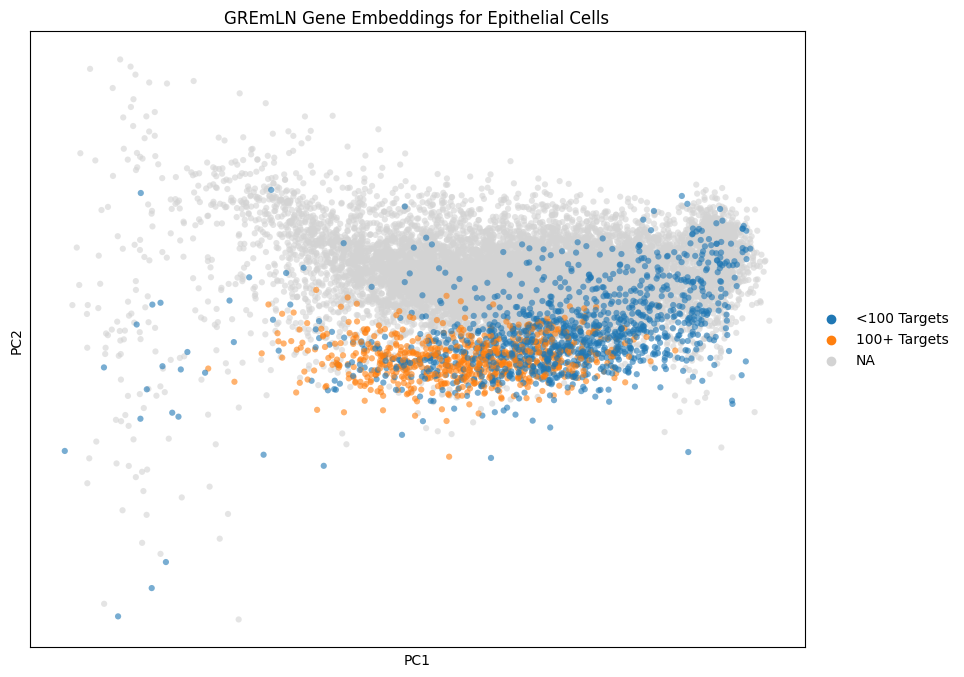

In [ ]:
# Plot gene embeddings colored by regulon size
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.pca(gene_emb, color="regulon_label", ax=ax, size=80, alpha=0.6, title="GREmLN Gene Embeddings for Epithelial Cells")

As shown above, gene embeddings signify regulatory influence. Genes with large regulons (more than 100 regulatory targets) are distinct from those with small regulons (less than 100 targets) and those with no regulatory role whatsoever (gray).

In [ ]:
# assign mean counts to quartiles
gene_emb.obs["mean_counts_quartile"] = pd.qcut(
    gene_emb.obs["mean_counts"],
    q=4, labels=["Q1", "Q2", "Q3", "Q4"]
)

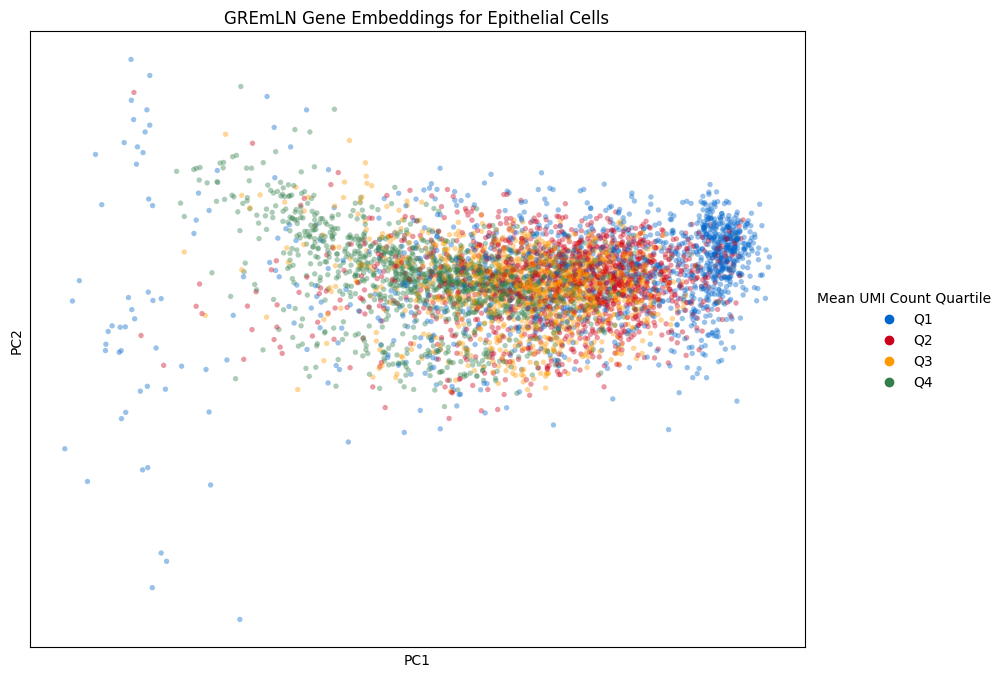

In [ ]:
# plot gene embeddings colored by mean UMI counts quartile
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.pca(
    adata=sc.pp.subsample(gene_emb, n_obs=5000, copy=True),
    color="mean_counts_quartile",
    ax=ax, size=60, alpha=0.4,
    palette=[(.0, .4, .8), (.8, 0, .1), (1.0, 0.6, 0.0), (.2, .5, 0.3)],
    title="GREmLN Gene Embeddings for Epithelial Cells",
    show=False
)
ax.get_legend().set_title("Mean UMI Count Quartile")

Gene embeddings also convey biological function. As shown above, the first principal component distinguishes genes based on their mean UMI count, a measurement which indicates commonness of gene acitvation. Commonly expressed genes tend to have housekeeping roles while rarely expressed genes determine the niche state of a cell.

## Model Outputs

GREmLN is a pretrained foundation model. Given processed gene expression data and a regulatory network, it's raw output is an 512-dimensional embedding vector for each expressed gene in cell, a `G x 512` matrix.

### Cell Embeddings
GREmLN's inference API provides support for reducing GREmLN's raw output to cell-level embeddings using via the `get_cell_embeddings` function. For a dataset of `C` cells, `get_cells_embeddings` will produce a dataframe of `C` rows and `512` columns, where row `i` represents the embedding for cell `i`.


### Gene Embeddings
GREmLN's inference API also provides support for reducing GREmLN's raw output to gene-level embeddings using via the `get_gene_embeddings` function. For a dataset of any number of cells, `get_cells_embeddings` will produce a dataframe of `G` rows and `512` columns, where row `i` represents the embedding for gene `i`, and `G` is the total number of expressed genes in the entire dataset.

## Contact and Acknowledgments

For issues with this quickstart please contact the developers:
- Mingxuan Zhang mz2934@cumc.columbia.edu
- Rowan Cassius rc3686@cumc.columbia.edu
- Léo Dupire ld3154@cumc.columbia.edu
- Vinay Swamy vss2134@cumc.columbia.edu

Special thank you to Maximilian Lombardo (mlombardo@chanzuckerberg.com) for their consultation on this quickstart.



## References
- **ARACNe** (Algorithm for the Reconstruction of Accurate Cellular Networks) https://califano.c2b2.columbia.edu/aracne/
- **PyTorch** – Deep learning framework https://pytorch.org/

- **PyTorch Lightning** – Lightweight PyTorch wrapper for high-performance training https://lightning.ai/docs/pytorch/stable/

- **FlashAttention** – Fast and memory-efficient attention for Transformers https://github.com/Dao-AILab/flash-attention

- **Torch Geometric** (PyG) – Graph neural networks for PyTorch
https://pytorch-geometric.readthedocs.io/

- **Scanpy** – scRNA-seq analysis in Python https://scanpy.readthedocs.io/

- **CELLxGENE** – Data portal for single-cell datasets https://cellxgene.cziscience.com/



## Responsible Use

We are committed to advancing the responsible development and use of artificial intelligence. Please follow our [Acceptable Use Policy](https://virtualcellmodels.cziscience.com/acceptable-use-policy) when engaging with our services.